# 01 Mdp Example

## 📚 Learning Objectives

By completing this notebook, you will:
- Formalize decision problems as MDPs
- Define states, actions, rewards, and transitions

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 1**.

---


## Before This Lesson: What Is Reinforcement Learning?

Reinforcement Learning (RL) is a branch of machine learning where an **agent** learns by interacting with an **environment** and receiving **rewards** based on its actions.

Instead of being shown the correct answer directly, the agent improves over time by trying actions, observing outcomes, and adjusting its behavior to achieve better long-term results.

In this course, students will move from the basic RL framework to classical methods, deep RL, exploration strategies, and practical applications.

Why start with MDPs? Because the MDP is the first precise model that helps students describe a decision problem before solving it with any RL algorithm.

So before asking *how the agent learns*, this lesson first answers a more basic question:

`How do we describe the world, the decisions, and the rewards in a form an RL system can understand?`

## Lesson Brief

This lesson introduces the basic language of reinforcement learning through a very small Markov Decision Process (MDP).

You will see what a **state**, **action**, **reward**, **transition**, and **policy** actually mean before any algorithm appears.

Why this matters: if students do not understand the MDP structure first, later topics like value iteration and Q-learning become formulas without meaning.

This notebook is the foundation for the rest of Unit 1.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- State: where the agent is.
- Action: what the agent can do.
- Reward: immediate feedback.
- Policy: the action rule.

### Quick Check
- Can you separate environment pieces from agent pieces?
- Why do we define states and actions before solving?
- What part of the notebook tells you what success means?

### Common Mistakes
- Mixing state with reward.
- Thinking the policy creates the reward.
- Reading one transition as the whole problem.


# Example 1: A Simple Markov Decision Process

This notebook gives you a concrete MDP before you move to policy evaluation,
policy iteration, and value iteration.

## What you should learn

By the end of this notebook, you should be able to:
- identify states, actions, rewards, and transitions in a simple problem
- describe an MDP using a small grid world
- read a policy as a mapping from states to actions
- understand why an MDP is the starting point for RL

## Before you start

You should already be comfortable with:
- basic Python syntax
- lists, dictionaries, and functions
- the RL terms `agent`, `environment`, and `reward`

## Study tip

Do not try to memorize definitions only.

Focus on answering this question:

`If I had to teach this problem to a computer, what information would I need to define first?`


## Inputs and Outputs

**Inputs**
- a tiny 3x3 grid world
- a small reward table
- a deterministic transition rule
- a hand-written example policy

**Outputs**
- a readable description of the MDP components
- example transitions from one state to the next
- a simple policy rollout showing how decisions accumulate reward


### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Example 1: Markov Decision Process (MDP)

1. States
[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

2. Actions
['up', 'right', 'down', 'left']

3. Rewards
  (0, 0): -0.1
  (0, 1): -0.1
  (0, 2): -0.1
  (1, 0): -0.1
  (1, 1): -3.0
  (1, 2): -0.1
  (2, 0): -0.1
  (2, 1): -0.1
  (2, 2): 5.0

4. Example transitions
  state=(0, 0), action=right -> next_state=(0, 1), reward=-0.1
  state=(0, 2), action=down -> next_state=(1, 2), reward=-0.1
  state=(1, 0), action=right -> next_state=(1, 1), reward=-3.0
  state=(2, 1), action=right -> next_state=(2, 2), reward=5.0

5. Example policy
  (0, 0) -> right
  (0, 1) -> right
  (0, 2) -> down
  (1, 0) -> down
  (1, 2) -> down
  (2, 0) -> right
  (2, 1) -> right

Checkpoint questions:
- Which parts of this problem belong to the environment?
- Which part represents the agent's decision rule?
- Why do we separate transitions from rewards?


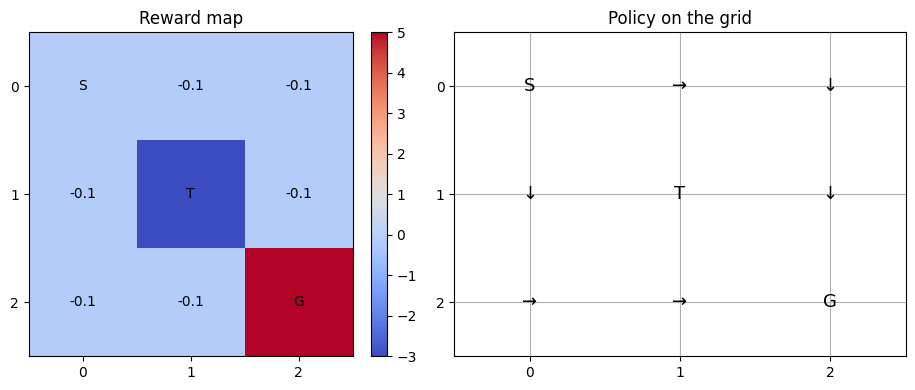

In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

import numpy as np
import matplotlib.pyplot as plt

# Keep the environment tiny so students can inspect every state by eye.
GRID_SIZE = 3

# The agent can choose one of four movement actions in each non-terminal state.
ACTIONS = ["up", "right", "down", "left"]
ACTION_TO_DELTA = {
    "up": (-1, 0),
    "right": (0, 1),
    "down": (1, 0),
    "left": (0, -1),
}
ACTION_TO_ARROW = {
    "up": "↑",
    "right": "→",
    "down": "↓",
    "left": "←",
}

# Name the important locations so they are easy to reference later.
START = (0, 0)
GOAL = (2, 2)
TRAP = (1, 1)
STEP_COST = -0.1

# Enumerate all possible states in the grid world.
states = [(r, c) for r in range(GRID_SIZE) for c in range(GRID_SIZE)]

# Rewards belong to the environment, not to the policy.
rewards = {state: STEP_COST for state in states}
rewards[GOAL] = 5.0
rewards[TRAP] = -3.0


def transition(state, action):
    # Terminal states stop the episode, so the agent stays there.
    if state in {GOAL, TRAP}:
        return state

    # Convert the chosen action into a movement on the grid.
    dr, dc = ACTION_TO_DELTA[action]
    nr = min(max(state[0] + dr, 0), GRID_SIZE - 1)
    nc = min(max(state[1] + dc, 0), GRID_SIZE - 1)
    return (nr, nc)


def draw_reward_and_policy_map(policy):
    # Build a 2D reward table so students can see the environment structure visually.
    reward_grid = np.array([[rewards[(r, c)] for c in range(GRID_SIZE)] for r in range(GRID_SIZE)])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Left: show where positive and negative rewards are placed.
    im = axes[0].imshow(reward_grid, cmap="coolwarm")
    axes[0].set_title("Reward map")
    axes[0].set_xticks(range(GRID_SIZE))
    axes[0].set_yticks(range(GRID_SIZE))
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == START:
                label = "S"
            elif state == GOAL:
                label = "G"
            elif state == TRAP:
                label = "T"
            else:
                label = f"{rewards[state]:.1f}"
            axes[0].text(c, r, label, ha="center", va="center", color="black")
    fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    # Right: show the policy separately so students distinguish rewards from decisions.
    axes[1].set_title("Policy on the grid")
    axes[1].set_xlim(-0.5, GRID_SIZE - 0.5)
    axes[1].set_ylim(GRID_SIZE - 0.5, -0.5)
    axes[1].set_xticks(range(GRID_SIZE))
    axes[1].set_yticks(range(GRID_SIZE))
    axes[1].grid(True)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == START:
                axes[1].text(c, r, "S", ha="center", va="center", fontsize=13)
            elif state == GOAL:
                axes[1].text(c, r, "G", ha="center", va="center", fontsize=13)
            elif state == TRAP:
                axes[1].text(c, r, "T", ha="center", va="center", fontsize=13)
            else:
                axes[1].text(c, r, ACTION_TO_ARROW[policy[state]], ha="center", va="center", fontsize=13)
    plt.tight_layout()
    plt.show()


# This hand-written policy intentionally goes around the trap and toward the goal.
policy = {
    (0, 0): "right",
    (0, 1): "right",
    (0, 2): "down",
    (1, 0): "down",
    (1, 2): "down",
    (2, 0): "right",
    (2, 1): "right",
}

print("=" * 60)
print("Example 1: Markov Decision Process (MDP)")
print("=" * 60)

print("\n1. States")
print(states)

print("\n2. Actions")
print(ACTIONS)

print("\n3. Rewards")
for state in states:
    print(f"  {state}: {rewards[state]}")

print("\n4. Example transitions")
examples = [
    (START, "right"),
    ((0, 2), "down"),
    ((1, 0), "right"),
    ((2, 1), "right"),
]
for state, action in examples:
    next_state = transition(state, action)
    print(
        f"  state={state}, action={action} -> next_state={next_state}, "
        f"reward={rewards[next_state]}"
    )

print("\n5. Example policy")
for state, action in policy.items():
    print(f"  {state} -> {action}")

print("\nCheckpoint questions:")
print("- Which parts of this problem belong to the environment?")
print("- Which part represents the agent's decision rule?")
print("- Why do we separate transitions from rewards?")

draw_reward_and_policy_map(policy)


## Worked Example: Following a Policy Through the MDP

Now that the MDP is defined, the next step is to see what happens when an agent
actually follows a policy.

In the next cell, you will simulate one short episode starting from the start
state and observe how rewards accumulate over time.

### Step Guide

**What this cell does:** This cell runs a worked example and shows the result through printed values, tables, or plots.

**Why this matters:** It is where the theory becomes concrete and students can connect the idea to actual behavior.

**What to expect in the output:** Expect visible output such as trajectories, value updates, rewards, comparisons, or charts.

**Common student confusion:** Students should compare the output with the comments and ask: what changed, why did it change, and what does that mean?


Policy rollout from the start state:

step 0: state=(0, 0), action=right, next_state=(0, 1), reward=-0.1
step 1: state=(0, 1), action=right, next_state=(0, 2), reward=-0.1
step 2: state=(0, 2), action=down, next_state=(1, 2), reward=-0.1
step 3: state=(1, 2), action=down, next_state=(2, 2), reward=5.0

Final state: (2, 2)
Total reward: 4.7

Reflection:
- Did the policy avoid the trap?
- What would happen if one action changed?
- How could a better policy be discovered automatically?


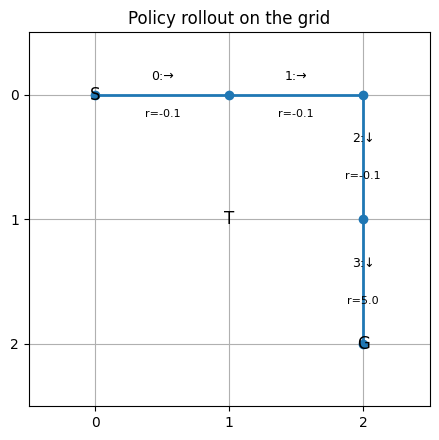

In [2]:
# Helper function: this block isolates one piece of logic so students can study it in one place.
# Focus on the inputs, the returned value, and why this step is needed in the larger workflow.

def rollout(policy, start_state=START, max_steps=10):
    state = start_state
    trajectory = []
    total_reward = 0.0

    for step_idx in range(max_steps):
        # Stop if the episode has already reached a terminal state.
        if state in {GOAL, TRAP}:
            break

        # The policy chooses an action for the current state.
        action = policy[state]

        # The environment responds with the next state.
        next_state = transition(state, action)

        # The reward is attached to the state the agent arrives in.
        reward = rewards[next_state]
        total_reward += reward

        # Save the full step so we can inspect the episode afterward.
        trajectory.append((step_idx, state, action, next_state, reward))
        state = next_state

        if state in {GOAL, TRAP}:
            break

    return trajectory, total_reward, state


def plot_trajectory(trajectory):
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.set_xlim(-0.5, GRID_SIZE - 0.5)
    ax.set_ylim(GRID_SIZE - 0.5, -0.5)
    ax.set_xticks(range(GRID_SIZE))
    ax.set_yticks(range(GRID_SIZE))
    ax.grid(True)
    ax.set_title("Policy rollout on the grid")

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            state = (r, c)
            if state == START:
                ax.text(c, r, "S", ha="center", va="center", fontsize=12)
            elif state == GOAL:
                ax.text(c, r, "G", ha="center", va="center", fontsize=12)
            elif state == TRAP:
                ax.text(c, r, "T", ha="center", va="center", fontsize=12)

    # Draw the visited path in order so students can see the sequence of decisions.
    path_points = [START] + [next_state for _, _, _, next_state, _ in trajectory]
    xs = [c for _, c in path_points]
    ys = [r for r, _ in path_points]
    ax.plot(xs, ys, marker="o", linewidth=2)

    # Annotate each move with the chosen action and received reward.
    for step_idx, (_, state, action, next_state, reward) in enumerate(trajectory):
        mid_x = (state[1] + next_state[1]) / 2
        mid_y = (state[0] + next_state[0]) / 2
        ax.text(mid_x, mid_y - 0.12, f"{step_idx}:{ACTION_TO_ARROW[action]}", ha="center", fontsize=9)
        ax.text(mid_x, mid_y + 0.18, f"r={reward}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.show()


trajectory, total_reward, final_state = rollout(policy)

print("Policy rollout from the start state:\n")
for step_idx, state, action, next_state, reward in trajectory:
    print(
        f"step {step_idx}: state={state}, action={action}, "
        f"next_state={next_state}, reward={reward}"
    )

print("\nFinal state:", final_state)
print("Total reward:", round(total_reward, 2))

print("\nReflection:")
print("- Did the policy avoid the trap?")
print("- What would happen if one action changed?")
print("- How could a better policy be discovered automatically?")

plot_trajectory(trajectory)


## Summary

You now have a concrete MDP in mind.

The important idea is not the grid itself. The important idea is the structure:
- states describe situations
- actions describe choices
- rewards describe feedback
- transitions describe how the world changes
- a policy describes how the agent behaves

### What comes next

In `02_mdp_solving.ipynb`, you will move from describing an MDP to solving one.

## 📚 References & Further Reading

**Books:**
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

**Papers:**
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

**State-of-the-Art:** OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.

### Step Guide

**What this cell does:** This cell turns the lesson outputs into a final visual recap.

**Why this matters:** Weak coders often understand charts faster than raw arrays or printed dictionaries.

**What to expect in the output:** Expect one or more plots that summarize the most important numbers from the notebook.

**Common student confusion:** Students should use this as a summary view after understanding the earlier steps, not as a replacement for them.


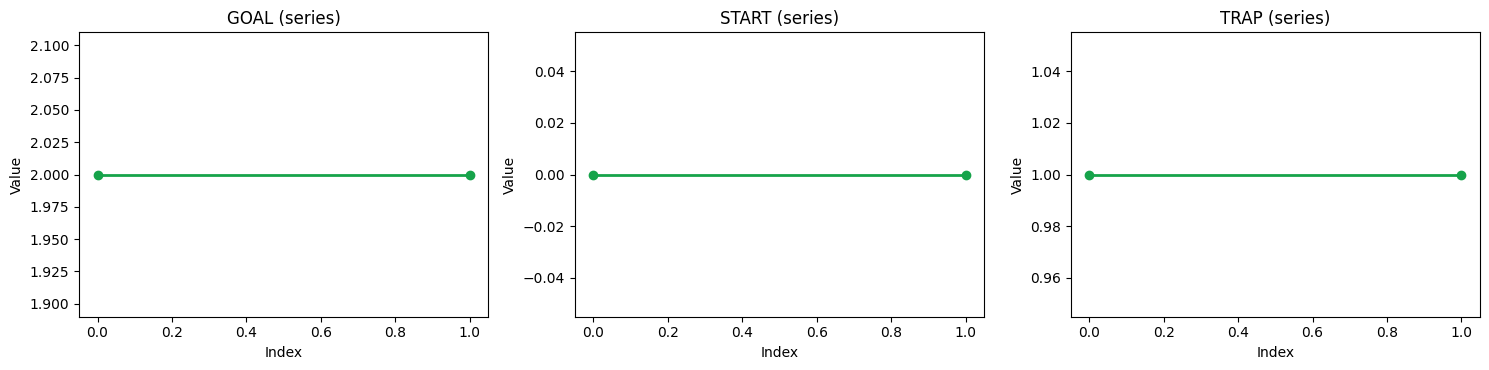

In [3]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
import numbers
import numpy as np
import matplotlib.pyplot as plt

def _is_number(value):
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

def _as_numeric_dict(value):
    if not isinstance(value, dict) or not value or len(value) > 12:
        return None
    converted = []
    for item in value.values():
        if not _is_number(item):
            return None
        converted.append(float(item))
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

def _as_numeric_array(value, dims):
    try:
        array = np.asarray(value, dtype=float)
    except Exception:
        return None
    if array.ndim != dims:
        return None
    if dims == 1 and not (2 <= array.size <= 200):
        return None
    if dims == 2 and array.size > 400:
        return None
    return array

priority_names = [
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
]

skip_names = {"np", "plt", "numbers", "math"}
candidates = []
seen = set()
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

for name in search_space:
    if name in seen or name not in globals() or name in skip_names:
        continue
    seen.add(name)
    value = globals()[name]

    dict_payload = _as_numeric_dict(value)
    if dict_payload is not None:
        candidates.append(("dict", name, dict_payload))
        if len(candidates) == 3:
            break
        continue

    array_2d = _as_numeric_array(value, 2)
    if array_2d is not None:
        candidates.append(("heatmap", name, array_2d))
        if len(candidates) == 3:
            break
        continue

    array_1d = _as_numeric_array(value, 1)
    if array_1d is not None:
        candidates.append(("line", name, array_1d))
        if len(candidates) == 3:
            break

if not candidates:
    summary = {
        "functions": sum(callable(value) for value in globals().values()),
        "classes": sum(isinstance(value, type) for value in globals().values()),
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    }
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    ax.set_title("Notebook artifact summary")
    ax.set_ylabel("Count")
    for idx, value in enumerate(summary.values()):
        ax.text(idx, value + 0.05, str(value), ha="center")
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    if len(candidates) == 1:
        axes = [axes]

    for ax, (kind, name, payload) in zip(axes, candidates):
        if kind == "dict":
            labels, values = payload
            ax.bar(range(len(values)), values, color="#2563eb")
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(labels, rotation=45, ha="right")
            ax.set_title(f"{name} (dict)")
            ax.set_ylabel("Value")
        elif kind == "line":
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            ax.set_title(f"{name} (series)")
            ax.set_xlabel("Index")
            ax.set_ylabel("Value")
        else:
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            ax.set_title(f"{name} (heatmap)")
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


## Closing Takeaway

**Teaching takeaway:** An MDP is the language that turns a decision problem into something an RL algorithm can work with: states, actions, rewards, transitions, and a policy.

**If students remember one idea:** Before solving a problem, define the environment clearly. A weak MDP definition creates weak RL reasoning later.

**Quick check before moving on:**
- Can you point to the state, action, reward, and transition rule in this example without looking back at the definitions?
- Can you explain why a policy is different from the environment dynamics?

**Bridge to the next step:** Next, you will move from describing an MDP to actually solving one.
